In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import numpy as np

In [32]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [33]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [34]:
#“Take this array and assign these column names”
X = pd.DataFrame(data.data, columns=data.feature_names)

y = pd.DataFrame(data.target, columns=data.target_names)

In [35]:
#X = pd.DataFrame(data.data, columns=data.feature_names)

#y = pd.DataFrame(data.target, columns=data.target_names)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)


mse_scores = -scores
print(mse_scores)
print("Average LR MSE:", np.mean(mse_scores))

[0.48485857 0.62249739 0.64621047 0.5431996  0.49468484]
Average LR MSE: 0.5582901717686568


In [ ]:
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)
models = {
    "Linear": model,
    "Ridge": ridge,
    "Lasso": lasso
}

for name, m in models.items():
    modelscores = cross_val_score(
    m,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)
    print(name, modelscores)
    print("Average ",m, " MSE:", -np.mean(modelscores))


Linear [-0.48485857 -0.62249739 -0.64621047 -0.5431996  -0.49468484]
Average  LinearRegression()  MSE: -0.5582901717686568
Ridge [-0.48472674 -0.6225366  -0.64621002 -0.54325965 -0.49466062]
Average  Ridge()  MSE: -0.55827872586856
Lasso [-0.52370056 -0.66805732 -0.70292794 -0.71816763 -0.69945272]
Average  Lasso(alpha=0.1)  MSE: -0.6624612332060622


In [37]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MSE: ", mean_squared_error(y_test, y_pred))
print("R^2: ", model.score(X_test, y_test))

y_trainpred = model.predict(X_train)
print("Training MSE: ", mean_squared_error(y_train, y_trainpred))

print("Test MSE: ", mean_squared_error(y_test, y_pred))

MSE:  0.5305677824766752
R^2:  0.5957702326061665
Training MSE:  0.5233576288267756
Test MSE:  0.5305677824766752


In [38]:

ridge.fit(X_train, y_train)

lasso.fit(X_train, y_train)
print("Linear:", model.coef_)
print("Ridge:", ridge.coef_)
print("Lasso:", lasso.coef_)

Linear: [[ 4.45822565e-01  9.68186799e-03 -1.22095112e-01  7.78599557e-01
  -7.75740400e-07 -3.37002667e-03 -4.18536747e-01 -4.33687976e-01]]
Ridge: [ 4.45640287e-01  9.68390676e-03 -1.21748570e-01  7.76670465e-01
 -7.70447401e-07 -3.36949165e-03 -4.18529602e-01 -4.33656145e-01]
Lasso: [ 3.90945460e-01  1.50604898e-02 -0.00000000e+00  0.00000000e+00
  1.83898356e-05 -3.06533920e-03 -1.15484247e-01 -1.01649021e-01]


In [39]:

models = {
    "Linear": model,
    "Ridge": ridge,
    "Lasso": lasso
}

for name, m in models.items():
    preds = m.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    print(name, mse)

Linear 0.5305677824766752
Ridge 0.5305052690933697
Lasso 0.5970512258509186


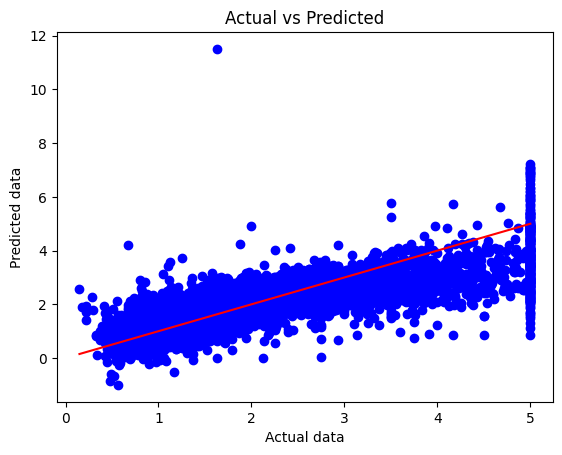

In [40]:
plt.scatter(y_test, y_pred, label="Actual data", color="blue")
#plt.plot(X_test, y_pred, label="Predicted data", color="red")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.xlabel("Actual data")
plt.ylabel("Predicted data")
plt.title("Actual vs Predicted")
plt.show()

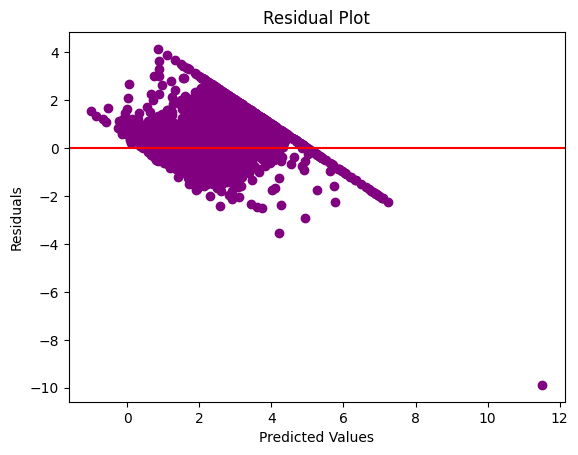

In [41]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color="purple")
plt.axhline(y=0, color="red")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

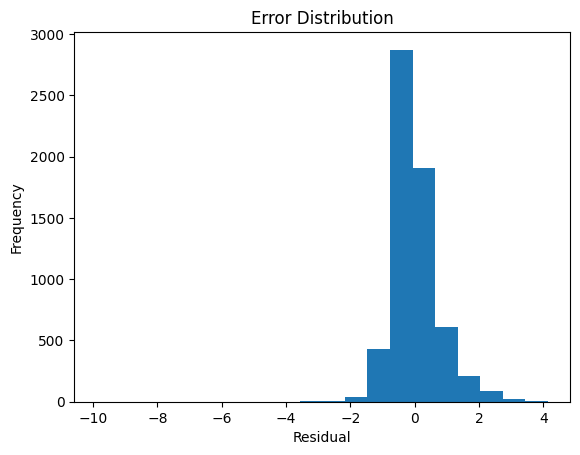

In [42]:
plt.hist(residuals, bins=20)
plt.title("Error Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

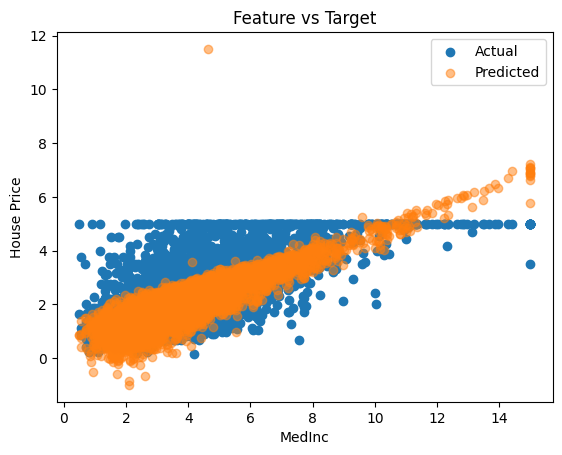

In [43]:
plt.scatter(X_test.iloc[:, 0], y_test, label="Actual")
plt.scatter(X_test.iloc[:, 0], y_pred, label="Predicted", alpha=0.5)
plt.xlabel(X_test.columns[0])
plt.ylabel("House Price")
plt.legend()
plt.title("Feature vs Target")
plt.show()

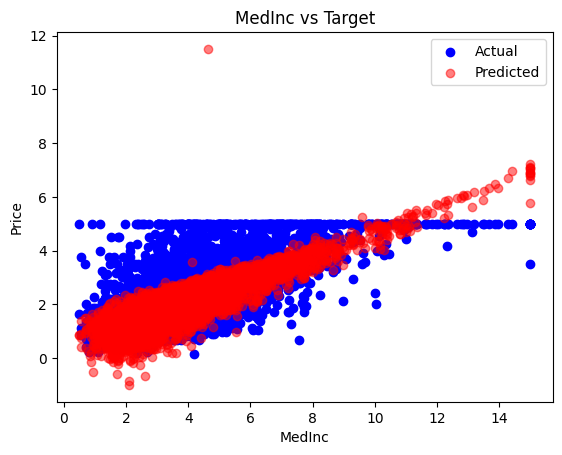

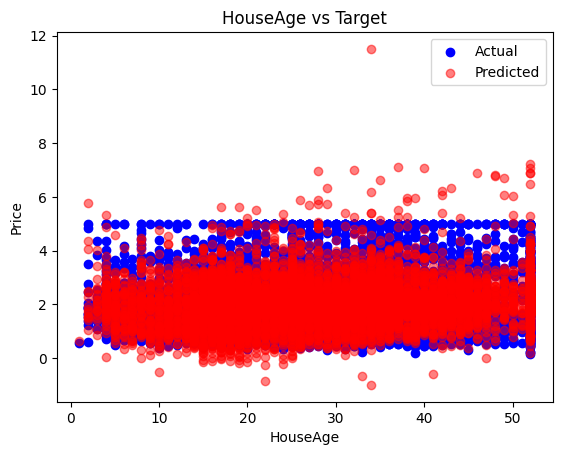

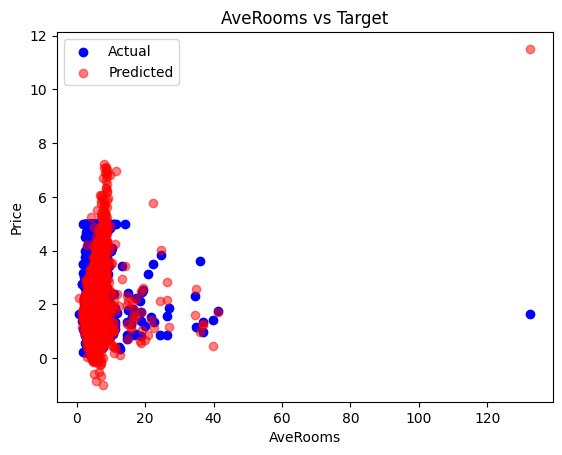

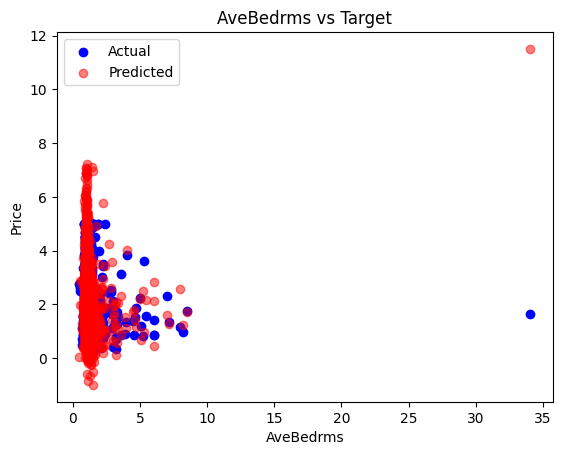

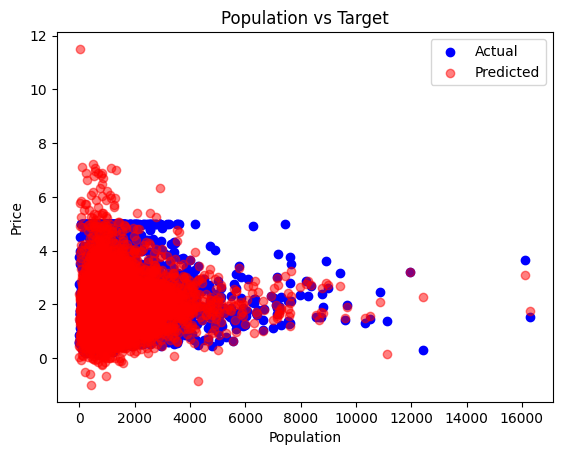

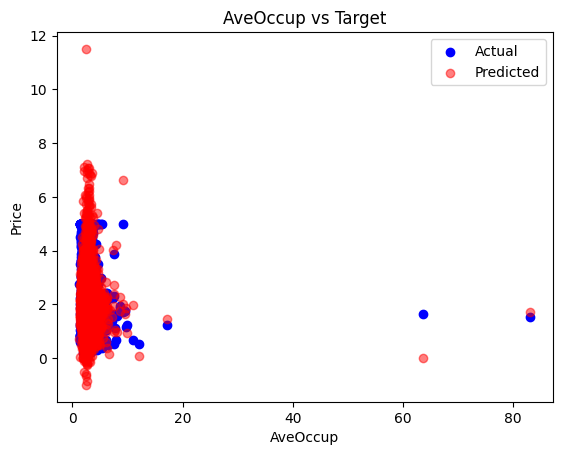

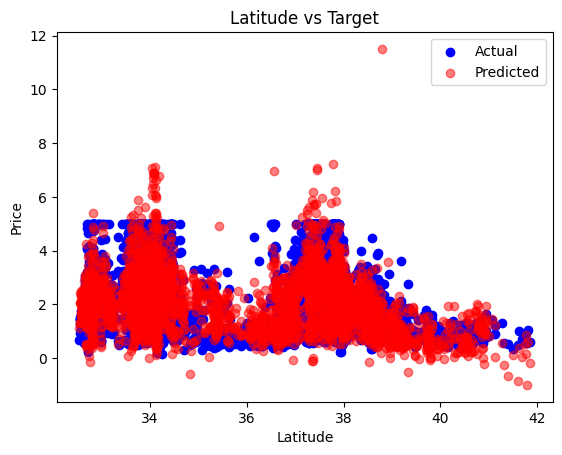

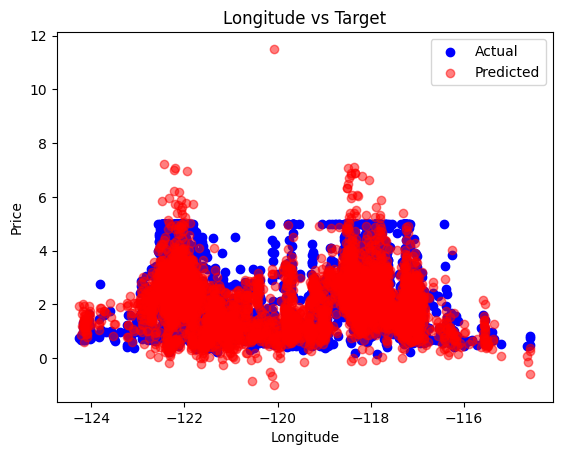

In [44]:
for col in X_test.columns:
    plt.figure()
    
    plt.scatter(X_test[col], y_test, color="blue", label="Actual")
    plt.scatter(X_test[col], y_pred, color="red", alpha=0.5, label="Predicted")
    
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.title(f"{col} vs Target")
    plt.legend()
    
    plt.show()

In [45]:
y_test_1d = np.ravel(y_test)
y_pred_1d = np.ravel(y_pred)

sns.scatterplot(x=y_test_1d, y=y_pred_1d)
plt.plot(
    [y_test_1d.min(), y_test_1d.max()],
    [y_test_1d.min(), y_test_1d.max()],
    color="red"
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

NameError: name 'sns' is not defined